# Lab 3

Description of lab:

Combining datasets, isolating data in datasets.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None) # to show all columns of a pandas Data Frame

In [4]:
from cycler import cycler

plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams["axes.labelsize"]= 12
plt.rcParams["figure.facecolor"] = "#f2f2f2"
#plt.rcParams['figure.savefig.dpi'] = 100
plt.rcParams['savefig.edgecolor'] = "#f2f2f2"
plt.rcParams['savefig.facecolor'] ="#f2f2f2"
plt.rcParams["figure.figsize"] = [16,10]
plt.rcParams['savefig.bbox'] = "tight"
plt.rcParams['font.size'] = 14
greens = ['#66c2a4','#41ae76','#238b45','#006d2c','#00441b']
multi =['#66c2a4','#1f78b4','#a6cee3','#b2df8a','#33a02c','#fb9a99','#e31a1c','#fdbf6f']
plt.rcParams["axes.prop_cycle"] = cycler(color=multi)

In [5]:
# Column 'province' is causing problems because of NaN values. I will excude it on import.
columnsToInclude = ['date', 'country', 'lat', 'long', 'type', 'cases', 'uid', 'iso2', 'iso3', 'code3', 'combined_key', 'population', 'continent_name', 'continent_code']

corona = pd.read_csv("https://jmaurit.github.io/anv_statistikk/data/coronavirus.csv")
corona

C:\Users\sebal\AppData\Local\Temp\ipykernel_18200\551260422.py:4: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  corona = pd.read_csv("https://jmaurit.github.io/anv_statistikk/data/coronavirus.csv")


,date,province,country,lat,long,type,cases,uid,iso2,iso3,code3,combined_key,population,continent_name,continent_code
0,2020-01-22,Alberta,Canada,53.933300,-116.576500,confirmed,0,12401.0,CA,CAN,124.0,"Alberta, Canada",4413146.0,North America,NaN
1,2020-01-23,Alberta,Canada,53.933300,-116.576500,confirmed,0,12401.0,CA,CAN,124.0,"Alberta, Canada",4413146.0,North America,NaN
2,2020-01-24,Alberta,Canada,53.933300,-116.576500,confirmed,0,12401.0,CA,CAN,124.0,"Alberta, Canada",4413146.0,North America,NaN
3,2020-01-25,Alberta,Canada,53.933300,-116.576500,confirmed,0,12401.0,CA,CAN,124.0,"Alberta, Canada",4413146.0,North America,NaN
4,2020-01-26,Alberta,Canada,53.933300,-116.576500,confirmed,0,12401.0,CA,CAN,124.0,"Alberta, Canada",4413146.0,North America,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
605545,2022-01-20,NaN,Zimbabwe,-19.015438,29.154857,recovery,0,716.0,ZW,ZWE,716.0,Zimbabwe,14862927.0,Africa,AF
605546,2022-01-21,NaN,Zimbabwe,-19.015438,29.154857,recovery,0,716.0,ZW,ZWE,716.0,Zimbabwe,14862927.0,Africa,AF
605547,2022-01-22,NaN,Zimbabwe,-19.015438,29.154857,recovery,0,716.0,ZW,ZWE,716.0,Zimbabwe,14862927.0,Africa,AF
605548,2022-01-23,NaN,Zimbabwe,-19.015438,29.154857,recovery,0,716.0,ZW,ZWE,716.0,Zimbabwe,14862927.0,Africa,AF


In [6]:
corona.shape

(605550, 15)

In [7]:
corona['type'].unique()

array(['confirmed', 'death', 'recovery'], dtype=object)

In [8]:
# Get only instances from a column that also coincides with two row conditions. Sum it up in this case.
corona.loc[(corona['country'] == 'Norway') & (corona['type'] == 'confirmed'), 'cases'].sum()

641138

In [9]:
# Get number of different cases for all countries. Split-Apply-Combine.
totals = corona.loc[corona['province'].isna(), :].groupby(['country', 'type'])['cases'].sum().reset_index()
totals

,country,type,cases
0,Afghanistan,confirmed,159896
1,Afghanistan,death,7393
2,Afghanistan,recovery,0
3,Albania,confirmed,248070
4,Albania,death,3305
...,...,...,...
575,Zambia,death,3900
576,Zambia,recovery,0
577,Zimbabwe,confirmed,228541
578,Zimbabwe,death,5305


In [10]:
totals[totals['type'] == 'confirmed'].sort_values(by = ['cases'], ascending = False)

,country,type,cases
538,US,confirmed,71708189
229,India,confirmed,39799202
66,Brazil,confirmed,24142032
178,France,confirmed,16446852
550,United Kingdom,confirmed,15953685
...,...,...,...
559,Vanuatu,confirmed,7
328,Marshall Islands,confirmed,7
265,Kiribati,confirmed,2
340,Micronesia,confirmed,1


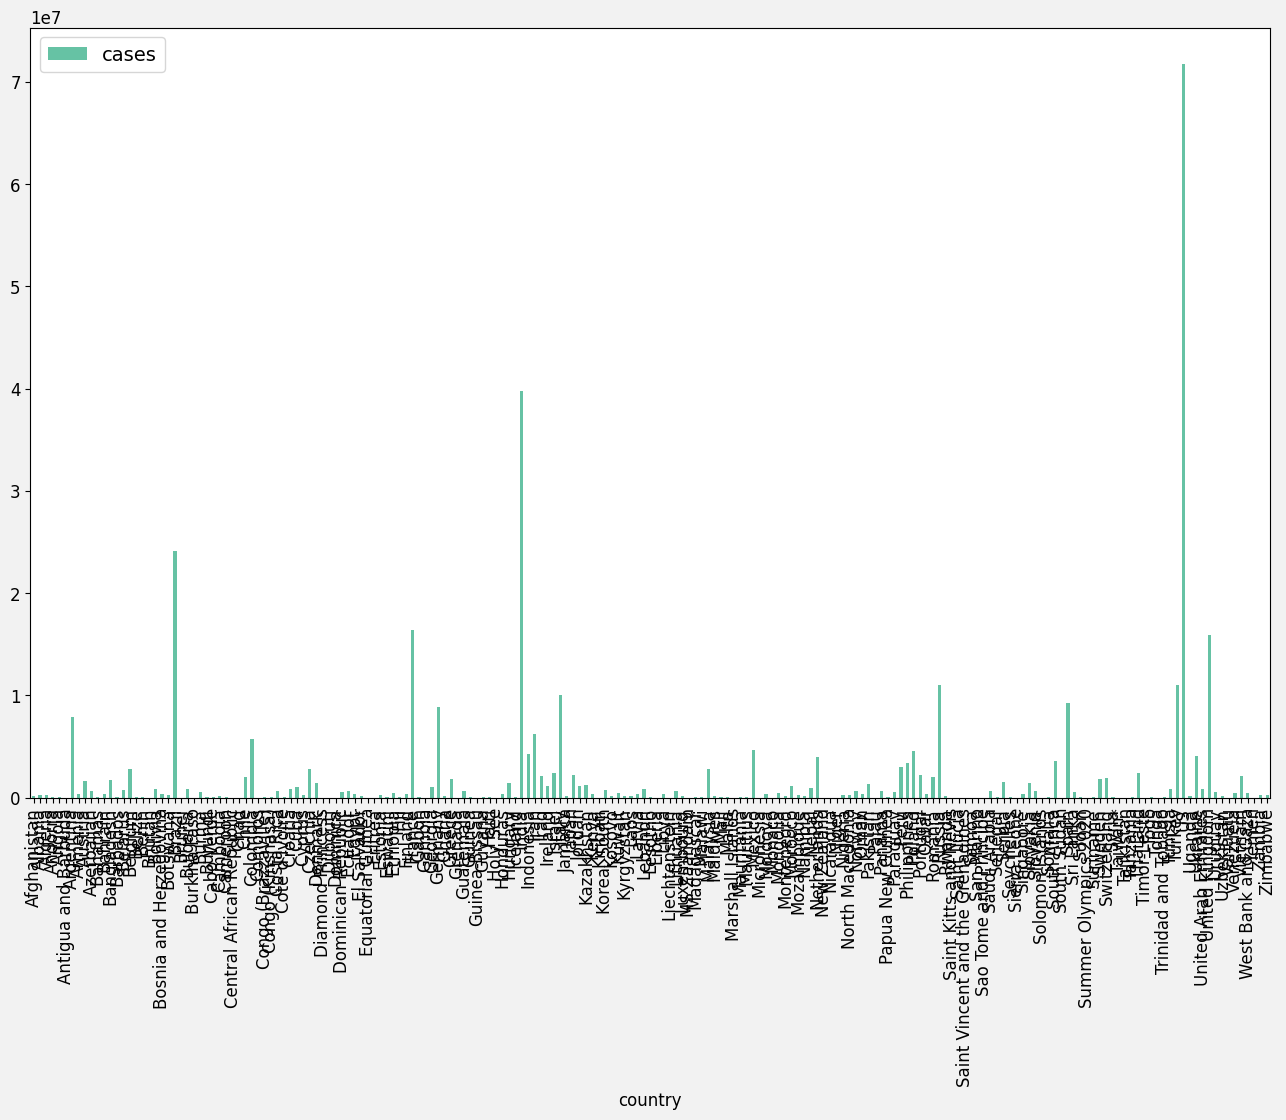

In [11]:
totals.loc[totals['type'] == 'confirmed', :].plot(x = 'country', y = 'cases', kind = 'bar')
plt.show()

In [12]:
nordics = ['Denmark', 'Finland', 'Norway', 'Sweden']

nordicCorona = corona.loc[(corona['country'].isin(nordics)) & (corona['province'].isna()), :]
nordicCorona

,date,province,country,lat,long,type,cases,uid,iso2,iso3,code3,combined_key,population,continent_name,continent_code
96154,2020-01-22,NaN,Denmark,56.263900,9.501800,confirmed,0,208.0,DK,DNK,208.0,Denmark,5792203.0,Europe,EU
96155,2020-01-23,NaN,Denmark,56.263900,9.501800,confirmed,0,208.0,DK,DNK,208.0,Denmark,5792203.0,Europe,EU
96156,2020-01-24,NaN,Denmark,56.263900,9.501800,confirmed,0,208.0,DK,DNK,208.0,Denmark,5792203.0,Europe,EU
96157,2020-01-25,NaN,Denmark,56.263900,9.501800,confirmed,0,208.0,DK,DNK,208.0,Denmark,5792203.0,Europe,EU
96158,2020-01-26,NaN,Denmark,56.263900,9.501800,confirmed,0,208.0,DK,DNK,208.0,Denmark,5792203.0,Europe,EU
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
586461,2022-01-20,NaN,Sweden,60.128161,18.643501,recovery,0,752.0,SE,SWE,752.0,Sweden,10099270.0,Europe,EU
586462,2022-01-21,NaN,Sweden,60.128161,18.643501,recovery,0,752.0,SE,SWE,752.0,Sweden,10099270.0,Europe,EU
586463,2022-01-22,NaN,Sweden,60.128161,18.643501,recovery,0,752.0,SE,SWE,752.0,Sweden,10099270.0,Europe,EU
586464,2022-01-23,NaN,Sweden,60.128161,18.643501,recovery,0,752.0,SE,SWE,752.0,Sweden,10099270.0,Europe,EU


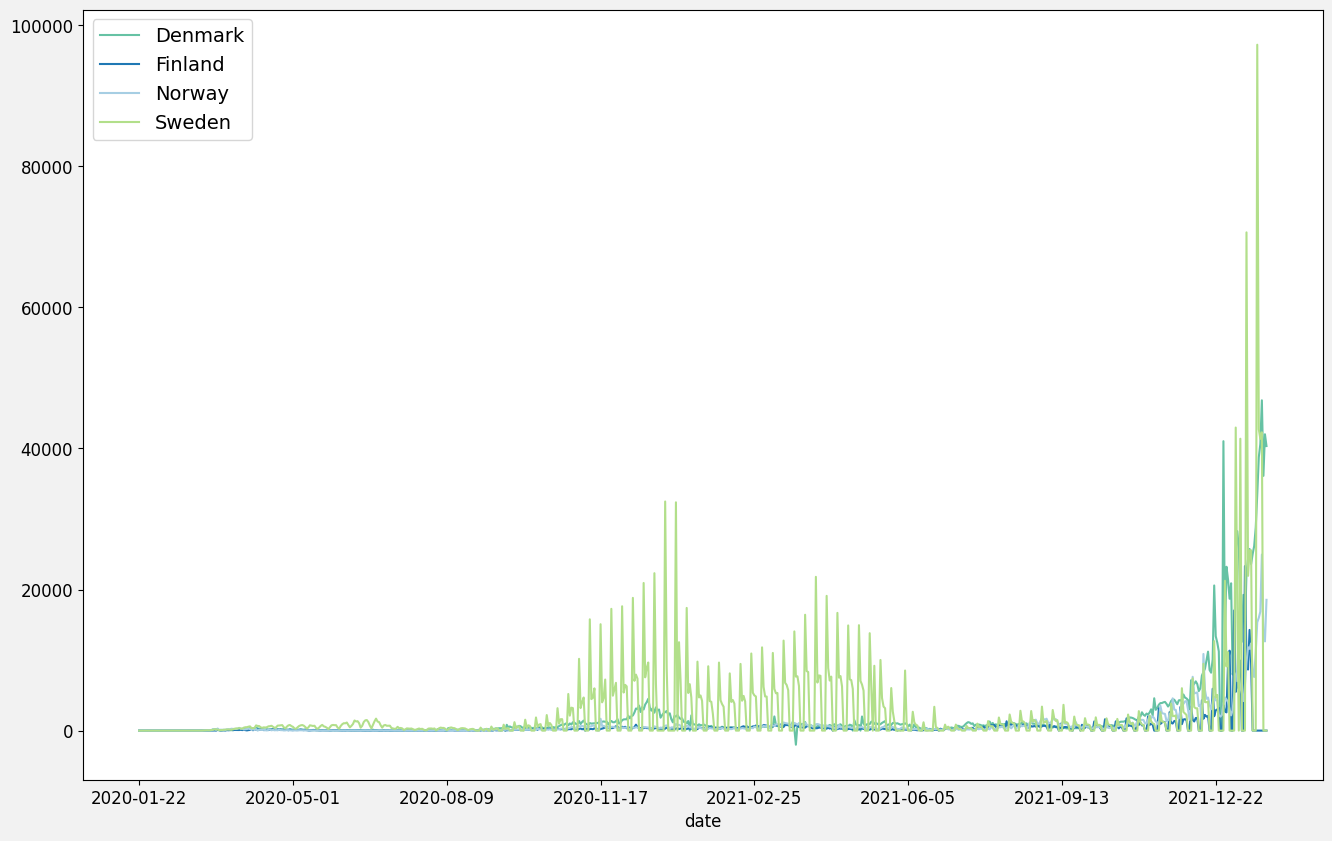

In [13]:
nordicCorona.loc[nordicCorona['type'] == 'confirmed'].set_index('date').groupby('country')['cases'].plot(legend = True)
plt.show()

### Aggregate and Transform

In [40]:
coronaSimple = corona.loc[(corona['type'] == 'confirmed') & (corona.province.isna()), :].copy()

summaryStats = coronaSimple.groupby(['country'])['cases'].aggregate(['min', 'max', 'median'])
summaryStats

,min,max,median
country,,,
Afghanistan,-6,3243,67.5
Albania,0,4789,152.5
Algeria,0,2215,217.5
Andorra,0,2313,8.0
Angola,0,5035,66.5
...,...,...,...
Vietnam,0,39132,9.0
West Bank and Gaza,0,30356,366.0
Yemen,-1,174,5.0


In [15]:
def diffMean(x):
    return x - x.mean()

In [16]:
coronaSimple['diffMeanCases'] = coronaSimple.groupby(['country'])['cases'].transform(diffMean)
coronaSimple

,date,province,country,lat,long,type,cases,uid,iso2,iso3,code3,combined_key,population,continent_name,continent_code,diffMeanCases
63858,2020-01-22,NaN,Afghanistan,33.939110,67.709953,confirmed,0,4.0,AF,AFG,4.0,Afghanistan,38928341.0,Asia,AS,-217.841962
63859,2020-01-23,NaN,Afghanistan,33.939110,67.709953,confirmed,0,4.0,AF,AFG,4.0,Afghanistan,38928341.0,Asia,AS,-217.841962
63860,2020-01-24,NaN,Afghanistan,33.939110,67.709953,confirmed,0,4.0,AF,AFG,4.0,Afghanistan,38928341.0,Asia,AS,-217.841962
63861,2020-01-25,NaN,Afghanistan,33.939110,67.709953,confirmed,0,4.0,AF,AFG,4.0,Afghanistan,38928341.0,Asia,AS,-217.841962
63862,2020-01-26,NaN,Afghanistan,33.939110,67.709953,confirmed,0,4.0,AF,AFG,4.0,Afghanistan,38928341.0,Asia,AS,-217.841962
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205515,2022-01-20,NaN,Zimbabwe,-19.015438,29.154857,confirmed,665,716.0,ZW,ZWE,716.0,Zimbabwe,14862927.0,Africa,AF,353.636240
205516,2022-01-21,NaN,Zimbabwe,-19.015438,29.154857,confirmed,409,716.0,ZW,ZWE,716.0,Zimbabwe,14862927.0,Africa,AF,97.636240
205517,2022-01-22,NaN,Zimbabwe,-19.015438,29.154857,confirmed,218,716.0,ZW,ZWE,716.0,Zimbabwe,14862927.0,Africa,AF,-93.363760
205518,2022-01-23,NaN,Zimbabwe,-19.015438,29.154857,confirmed,75,716.0,ZW,ZWE,716.0,Zimbabwe,14862927.0,Africa,AF,-236.363760


In [17]:
prices2019 = pd.read_csv("https://jmaurit.github.io/anv_statistikk/data/prices2019.csv", sep=";", decimal=",")
prices2020 = pd.read_csv("https://jmaurit.github.io/anv_statistikk/data/prices2020.csv", sep=";", decimal=",")

In [18]:
print('2019:', prices2019.shape, '\n2020:', prices2020.shape)

2019: (8761, 24) 
2020: (7056, 24)


In [19]:
prices2019 = prices2019.rename(columns = dict(zip(prices2019.columns, prices2020.columns)))

In [20]:
prices2019

,date,Hours,SYS,SE1,SE2,SE3,SE4,FI,DK1,DK2,Oslo,Kr.sand,Bergen,Molde,Tr.heim,Tromsø,EE,LV,LT,AT,BE,DE-LU,FR,NL
0,01/01/2019,00 - 01,44.55,28.32,28.32,28.32,28.32,28.32,28.32,28.32,48.77,48.77,48.77,45.36,45.36,45.36,28.32,28.32,28.32,NaN,NaN,NaN,NaN,NaN
1,01/01/2019,01 - 02,44.07,10.07,10.07,10.07,10.07,10.07,10.07,10.07,49.25,49.25,49.25,45.31,45.31,45.31,10.07,10.07,10.07,NaN,NaN,NaN,NaN,NaN
2,01/01/2019,02 - 03,41.12,10.03,10.03,10.03,10.03,10.03,-4.08,-4.08,49.17,49.17,49.17,45.37,45.37,45.37,10.03,10.03,10.03,NaN,NaN,NaN,NaN,NaN
3,01/01/2019,03 - 04,38.88,4.56,4.56,4.56,4.56,4.56,-9.91,-9.91,48.37,48.37,48.37,45.21,45.21,45.21,4.56,4.56,4.56,NaN,NaN,NaN,NaN,NaN
4,01/01/2019,04 - 05,35.70,4.83,4.83,4.83,4.83,4.83,-7.41,-7.41,47.19,47.19,47.19,44.90,44.90,44.90,4.83,4.83,4.83,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8756,31/12/2019,19 - 20,33.30,32.37,32.37,32.37,32.37,32.37,33.85,33.85,33.85,33.85,33.85,32.37,32.37,32.37,32.37,32.37,32.37,46.00,46.00,46.00,46.00,46.00
8757,31/12/2019,20 - 21,32.30,31.23,31.23,31.23,31.23,31.23,33.54,33.54,33.54,33.54,33.54,31.23,31.23,31.23,31.23,31.23,31.23,42.20,42.20,42.20,42.20,42.20
8758,31/12/2019,21 - 22,32.17,31.33,31.33,31.33,31.33,31.33,33.17,33.17,33.17,33.17,33.17,31.33,31.33,31.33,31.33,31.33,31.33,39.74,39.74,39.74,39.74,39.74
8759,31/12/2019,22 - 23,32.08,31.46,31.46,31.46,31.46,31.46,33.04,33.04,32.75,32.75,32.75,31.46,31.46,31.46,31.46,31.46,31.46,38.88,38.88,38.88,38.88,38.88


In [21]:
prices = pd.concat([prices2019, prices2020], axis = 0)
prices

,date,Hours,SYS,SE1,SE2,SE3,SE4,FI,DK1,DK2,Oslo,Kr.sand,Bergen,Molde,Tr.heim,Tromsø,EE,LV,LT,AT,BE,DE-LU,FR,NL
0,01/01/2019,00 - 01,44.55,28.32,28.32,28.32,28.32,28.32,28.32,28.32,48.77,48.77,48.77,45.36,45.36,45.36,28.32,28.32,28.32,NaN,NaN,NaN,NaN,NaN
1,01/01/2019,01 - 02,44.07,10.07,10.07,10.07,10.07,10.07,10.07,10.07,49.25,49.25,49.25,45.31,45.31,45.31,10.07,10.07,10.07,NaN,NaN,NaN,NaN,NaN
2,01/01/2019,02 - 03,41.12,10.03,10.03,10.03,10.03,10.03,-4.08,-4.08,49.17,49.17,49.17,45.37,45.37,45.37,10.03,10.03,10.03,NaN,NaN,NaN,NaN,NaN
3,01/01/2019,03 - 04,38.88,4.56,4.56,4.56,4.56,4.56,-9.91,-9.91,48.37,48.37,48.37,45.21,45.21,45.21,4.56,4.56,4.56,NaN,NaN,NaN,NaN,NaN
4,01/01/2019,04 - 05,35.70,4.83,4.83,4.83,4.83,4.83,-7.41,-7.41,47.19,47.19,47.19,44.90,44.90,44.90,4.83,4.83,4.83,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7051,20/10/2020,19 - 20,21.74,28.81,28.81,34.92,43.47,64.01,37.05,43.47,19.30,19.30,19.30,17.38,17.38,12.85,64.01,64.01,64.01,49.02,49.02,49.02,49.02,49.02
7052,20/10/2020,20 - 21,20.42,25.95,25.95,25.95,25.95,29.06,25.95,25.95,19.48,19.48,19.48,17.32,17.32,12.66,29.06,29.06,29.06,42.25,45.05,38.06,44.83,40.93
7053,20/10/2020,21 - 22,19.57,20.11,20.11,20.11,20.11,23.44,20.11,20.11,19.86,19.86,19.86,17.26,17.26,12.49,23.44,23.44,23.44,37.40,41.00,33.09,40.51,37.40
7054,20/10/2020,22 - 23,19.23,19.44,19.44,19.44,19.44,23.54,19.44,19.44,19.44,19.44,19.44,17.18,17.18,12.41,23.54,23.54,23.54,32.52,44.63,29.66,38.04,44.63


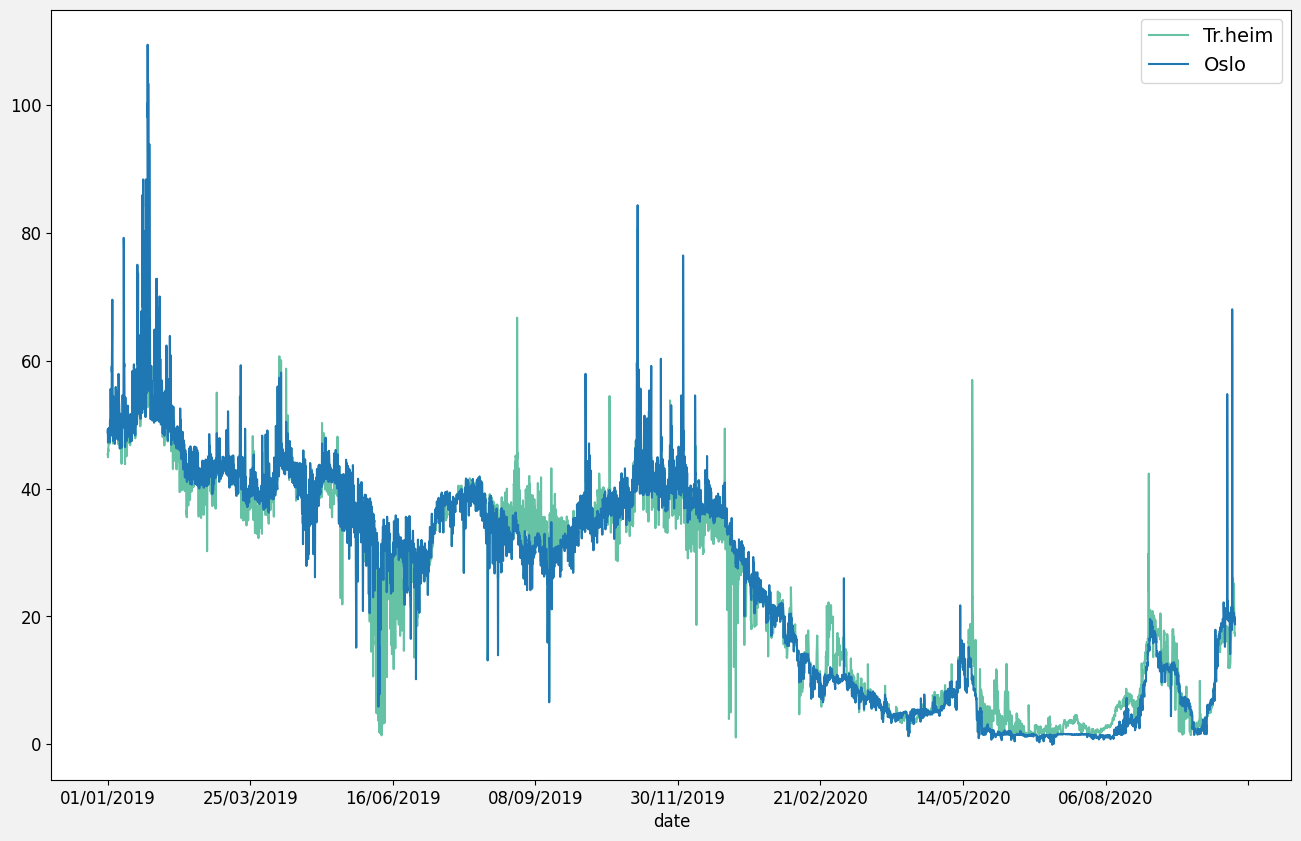

In [22]:
prices.loc[:, ['date', 'Tr.heim', 'Oslo']].set_index('date').plot()
plt.show()

Merging

In [23]:
pwt = pd.read_csv("https://jmaurit.github.io/anv_statistikk/data/pwt100.csv", sep=";", decimal=",")

In [24]:
pwt2019 = pwt.loc[pwt['year'] == 2019].copy()

In [25]:
totals

,country,type,cases
0,Afghanistan,confirmed,159896
1,Afghanistan,death,7393
2,Afghanistan,recovery,0
3,Albania,confirmed,248070
4,Albania,death,3305
...,...,...,...
575,Zambia,death,3900
576,Zambia,recovery,0
577,Zimbabwe,confirmed,228541
578,Zimbabwe,death,5305


In [26]:
pwt2019Plus = pd.merge(pwt2019, totals.loc[totals['type'] == 'confirmed'], on = 'country', how = 'left')

In [27]:
pwt2019Plus.loc[pwt2019Plus['country'].isin(nordics)].sort_values(by = ['cases'], ascending = False)

,countrycode,country,currency_unit,year,rgdpe,rgdpo,pop,emp,avh,hc,ccon,cda,cgdpe,cgdpo,cn,ck,ctfp,cwtfp,rgdpna,rconna,rdana,rnna,rkna,rtfpna,rwtfpna,labsh,irr,delta,xr,pl_con,pl_da,pl_gdpo,i_cig,i_xm,i_xr,i_outlier,i_irr,cor_exp,statcap,csh_c,csh_i,csh_g,csh_x,csh_m,csh_r,pl_c,pl_i,pl_g,pl_x,pl_m,pl_n,pl_k,type,cases
154,SWE,Sweden,Swedish Krona,2019,560960.5000,526240.8125,10.036379,5.002137,1605.276602,3.435986,385172.6563,539628.1250,559511.0625,527787.8125,2743785.00,0.037234,0.812524,0.798991,532053.6875,383728.4688,541234.1875,2757360.250,1.038183,1.010664,0.998263,0.556666,0.056162,0.041834,9.458349,0.981510,0.948835,1.005866,Extrapolated,Extrapolated,Market-based,Regular,Regular,NaN,NaN,0.466308,0.292647,0.263479,0.444346,-0.499286,0.032506,0.978411,0.867354,0.986993,0.684665,0.603221,0.884888,0.731984,confirmed,1784005.0
49,DNK,Denmark,Danish Krone,2019,322637.5000,311838.0000,5.771876,2.971837,1380.607643,3.599265,205815.2813,297974.6563,321613.5625,312004.0625,1594880.00,0.021040,0.914099,0.839620,311263.6563,205050.1250,298115.4688,1598105.625,1.039088,1.026076,1.017730,0.620392,0.058174,0.042992,6.669447,1.189721,1.088587,1.122115,Extrapolated,Extrapolated,Market-based,Regular,Regular,NaN,NaN,0.446605,0.295379,0.213050,0.523103,-0.515129,0.036991,1.158099,0.862730,1.256008,0.673928,0.604830,0.835327,0.731464,confirmed,1438181.0
127,NOR,Norway,Norwegian Krone,2019,336415.4063,396253.8750,5.378857,2.853662,1384.073291,3.662843,216700.5156,329255.8750,335132.2500,388492.4688,1723067.25,0.023208,1.030040,0.839606,377715.3438,215975.7969,329937.8125,1723175.125,1.054514,0.977179,0.996919,0.528504,0.061986,0.038229,8.800000,1.288979,1.203514,1.038209,Extrapolated,Extrapolated,Market-based,Regular,Regular,NaN,NaN,0.374180,0.289723,0.183618,0.513056,-0.333770,-0.026808,1.243976,1.038969,1.380687,0.521929,0.664356,0.978130,0.948889,confirmed,641138.0
57,FIN,Finland,Euro,2019,261017.3438,248551.5469,5.532156,2.673705,1590.694538,3.504452,193049.7813,259182.4063,260316.4844,249282.9844,1281196.50,0.015576,0.806986,0.806956,248022.4219,192498.3281,259878.7813,1284489.125,1.037011,0.984099,0.980636,0.571272,0.061210,0.037876,0.893276,1.051617,1.034496,1.080284,Extrapolated,Extrapolated,Market-based,Regular,Regular,NaN,NaN,0.543935,0.265291,0.230485,0.432648,-0.479986,0.007627,1.040508,0.984516,1.077835,0.675364,0.616117,0.917873,0.858353,confirmed,371135.0


In [28]:
pwt2019Plus['cases'].isna().value_counts()

cases
False    148
True      35
Name: count, dtype: int64

In [29]:
pwt2019Plus = pwt2019Plus.dropna(subset = ['cases']).copy()
pwt2019Plus

,countrycode,country,currency_unit,year,rgdpe,rgdpo,pop,emp,avh,hc,ccon,cda,cgdpe,cgdpo,cn,ck,ctfp,cwtfp,rgdpna,rconna,rdana,rnna,rkna,rtfpna,rwtfpna,labsh,irr,delta,xr,pl_con,pl_da,pl_gdpo,i_cig,i_xm,i_xr,i_outlier,i_irr,cor_exp,statcap,csh_c,csh_i,csh_g,csh_x,csh_m,csh_r,pl_c,pl_i,pl_g,pl_x,pl_m,pl_n,pl_k,type,cases
1,AGO,Angola,Kwanza,2019,228151.01560,227855.71880,31.825295,16.644962,NaN,1.481984,155943.71880,198750.42190,227771.60940,223289.31250,1.371321e+06,0.017415,0.380317,0.325579,222151.06250,155270.70310,198864.73440,1.367458e+06,1.003396,0.937804,0.917951,0.331142,0.109524,0.043388,364.825805,0.381504,0.373184,0.380675,Extrapolated,Extrapolated,Market-based,Regular,Regular,NaN,48.888900,0.498670,0.191710,0.199723,0.344351,-0.113983,-1.204703e-01,0.438169,0.342872,0.240024,0.476486,0.611627,0.209101,0.378033,confirmed,97263.0
3,ALB,Albania,Lek,2019,35890.01953,36103.04297,2.880917,1.075898,NaN,2.964992,33399.16797,40868.31641,35808.34375,36288.32813,2.298183e+05,NaN,NaN,NaN,37204.77344,33426.44141,40984.56250,2.278046e+05,NaN,NaN,NaN,NaN,NaN,0.027732,109.850833,0.419904,0.426662,0.421019,Extrapolated,Extrapolated,Market-based,Regular,NaN,NaN,78.888900,0.714312,0.205828,0.206071,0.126594,-0.313949,6.114468e-02,0.473077,0.456882,0.235589,0.629832,0.525463,0.299344,NaN,confirmed,248070.0
4,ARE,United Arab Emirates,UAE Dirham,2019,681525.81250,645956.25000,9.770529,5.808834,NaN,2.746695,306771.15630,515623.31250,678241.18750,635332.81250,4.510360e+06,NaN,NaN,NaN,647986.25000,306717.03130,533594.31250,4.506529e+06,NaN,NaN,NaN,NaN,NaN,0.036909,3.672500,0.716486,0.620933,0.662869,Extrapolated,Extrapolated,Market-based,Regular,NaN,NaN,NaN,0.355746,0.328729,0.127105,0.889652,-0.701231,-4.849210e-07,0.725061,0.480580,0.692488,0.688882,0.647336,0.268754,NaN,confirmed,828328.0
5,ARG,Argentina,Argentine Peso,2019,991646.31250,977420.56250,44.780677,20.643215,1609.068998,3.096804,826692.56250,930002.37500,991465.43750,978558.81250,3.374818e+06,0.031312,0.812184,0.742373,975569.00000,822399.56250,921896.50000,3.399148e+06,1.022263,0.931501,0.875393,0.543918,0.119156,0.035492,48.147892,0.433224,0.453534,0.459516,Extrapolated,Extrapolated,Market-based,Regular,Regular,NaN,80.000000,0.620383,0.105573,0.224423,0.102728,-0.079542,2.643427e-02,0.476809,0.616060,0.312739,0.647736,0.631130,0.377946,0.758450,confirmed,7940657.0
6,ARM,Armenia,Armenian Dram,2019,41048.62891,43582.57422,2.957731,0.966091,NaN,3.135995,42821.80469,46950.61328,41045.19141,43795.68750,9.894587e+04,0.001158,0.820758,0.846244,43260.19531,43101.31250,47185.84766,9.881277e+04,1.059019,1.136326,1.167809,0.548672,0.093098,0.032632,480.445129,0.309525,0.333116,0.312195,Extrapolated,Extrapolated,Market-based,Regular,Regular,NaN,93.333367,0.757310,0.094274,0.220453,0.089798,-0.197262,3.542698e-02,0.348213,0.577787,0.176624,0.666217,0.587048,0.432372,0.617077,confirmed,352399.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174,UZB,Uzbekistan,Uzbekistan Sum,2019,378534.25000,414768.46880,32.981716,14.624535,NaN,NaN,344205.15630,419838.34380,379531.21880,416046.56250,1.162961e+06,0.015374,NaN,NaN,395524.28130,343965.62500,443774.71880,1.168223e+06,1.327171,NaN,NaN,0.427632,0.160069,0.051519,8836.787500,0.119167,0.152613,0.139218,Extrapolated,Extrapolated,Market-based,Outlier,Regular,NaN,64.444433,0.353068,0.181790,0.474256,0.059052,-0.081743,1.357681e-02,0.214632,0.304824,0.048096,0.607671,0.642990,0.108770,0.249714,confirmed,215063.0
179,YEM,Yemen,Yemeni Rial,2019,50052.93359,51828.05859,29.161922,5.531877,NaN,1.842989,49266.47266,67992.53125,49937.04297,51983.42969,5.485533e+05,NaN,NaN,NaN,40069.59375,49169.07031,64330.73828,5.502327e+05,NaN,NaN,NaN,NaN,NaN,0.029836,250.250000,0.598363,0.499337,0.479680,Extrapolated,Extrapolated,Market-based,Regular,NaN,NaN,38.888867,0.647500,0.360231,0.300234,0.000723

In [30]:
pwt2019Plus['cases'].isna().value_counts()

cases
False    148
Name: count, dtype: int64

In [31]:
pwt2019Plus['rgdpe_per_pers'] = pwt2019Plus.loc[:, 'rgdpe'] / pwt2019Plus.loc[:, 'pop']

In [32]:
pwt2019Plus['cases_per_pers'] = pwt2019Plus.loc[:, 'cases'] / (pwt2019Plus.loc[:, 'pop'] * 1000000)

In [33]:
pwt2019Plus.head()

,countrycode,country,currency_unit,year,rgdpe,rgdpo,pop,emp,avh,hc,ccon,cda,cgdpe,cgdpo,cn,ck,ctfp,cwtfp,rgdpna,rconna,rdana,rnna,rkna,rtfpna,rwtfpna,labsh,irr,delta,xr,pl_con,pl_da,pl_gdpo,i_cig,i_xm,i_xr,i_outlier,i_irr,cor_exp,statcap,csh_c,csh_i,csh_g,csh_x,csh_m,csh_r,pl_c,pl_i,pl_g,pl_x,pl_m,pl_n,pl_k,type,cases,rgdpe_per_pers,cases_per_pers
1,AGO,Angola,Kwanza,2019,228151.01560,227855.71880,31.825295,16.644962,NaN,1.481984,155943.71880,198750.42190,227771.60940,223289.31250,1.371321e+06,0.017415,0.380317,0.325579,222151.06250,155270.70310,198864.73440,1.367458e+06,1.003396,0.937804,0.917951,0.331142,0.109524,0.043388,364.825805,0.381504,0.373184,0.380675,Extrapolated,Extrapolated,Market-based,Regular,Regular,NaN,48.888900,0.498670,0.191710,0.199723,0.344351,-0.113983,-1.204703e-01,0.438169,0.342872,0.240024,0.476486,0.611627,0.209101,0.378033,confirmed,97263.0,7168.857841,0.003056
3,ALB,Albania,Lek,2019,35890.01953,36103.04297,2.880917,1.075898,NaN,2.964992,33399.16797,40868.31641,35808.34375,36288.32813,2.298183e+05,NaN,NaN,NaN,37204.77344,33426.44141,40984.56250,2.278046e+05,NaN,NaN,NaN,NaN,NaN,0.027732,109.850833,0.419904,0.426662,0.421019,Extrapolated,Extrapolated,Market-based,Regular,NaN,NaN,78.888900,0.714312,0.205828,0.206071,0.126594,-0.313949,6.114468e-02,0.473077,0.456882,0.235589,0.629832,0.525463,0.299344,NaN,confirmed,248070.0,12457.845724,0.086108
4,ARE,United Arab Emirates,UAE Dirham,2019,681525.81250,645956.25000,9.770529,5.808834,NaN,2.746695,306771.15630,515623.31250,678241.18750,635332.81250,4.510360e+06,NaN,NaN,NaN,647986.25000,306717.03130,533594.31250,4.506529e+06,NaN,NaN,NaN,NaN,NaN,0.036909,3.672500,0.716486,0.620933,0.662869,Extrapolated,Extrapolated,Market-based,Regular,NaN,NaN,NaN,0.355746,0.328729,0.127105,0.889652,-0.701231,-4.849210e-07,0.725061,0.480580,0.692488,0.688882,0.647336,0.268754,NaN,confirmed,828328.0,69753.215256,0.084778
5,ARG,Argentina,Argentine Peso,2019,991646.31250,977420.56250,44.780677,20.643215,1609.068998,3.096804,826692.56250,930002.37500,991465.43750,978558.81250,3.374818e+06,0.031312,0.812184,0.742373,975569.00000,822399.56250,921896.50000,3.399148e+06,1.022263,0.931501,0.875393,0.543918,0.119156,0.035492,48.147892,0.433224,0.453534,0.459516,Extrapolated,Extrapolated,Market-based,Regular,Regular,NaN,80.000000,0.620383,0.105573,0.224423,0.102728,-0.079542,2.643427e-02,0.476809,0.616060,0.312739,0.647736,0.631130,0.377946,0.758450,confirmed,7940657.0,22144.513637,0.177323
6,ARM,Armenia,Armenian Dram,2019,41048.62891,43582.57422,2.957731,0.966091,NaN,3.135995,42821.80469,46950.61328,41045.19141,43795.68750,9.894587e+04,0.001158,0.820758,0.846244,43260.19531,43101.31250,47185.84766,9.881277e+04,1.059019,1.136326,1.167809,0.548672,0.093098,0.032632,480.445129,0.309525,0.333116,0.312195,Extrapolated,Extrapolated,Market-based,Regular,Regular,NaN,93.333367,0.757310,0.094274,0.220453,0.089798,-0.197262,3.542698e-02,0.348213,0.577787,0.176624,0.666217,0.587048,0.432372,0.617077,confirmed,352399.0,13878.418595,0.119145


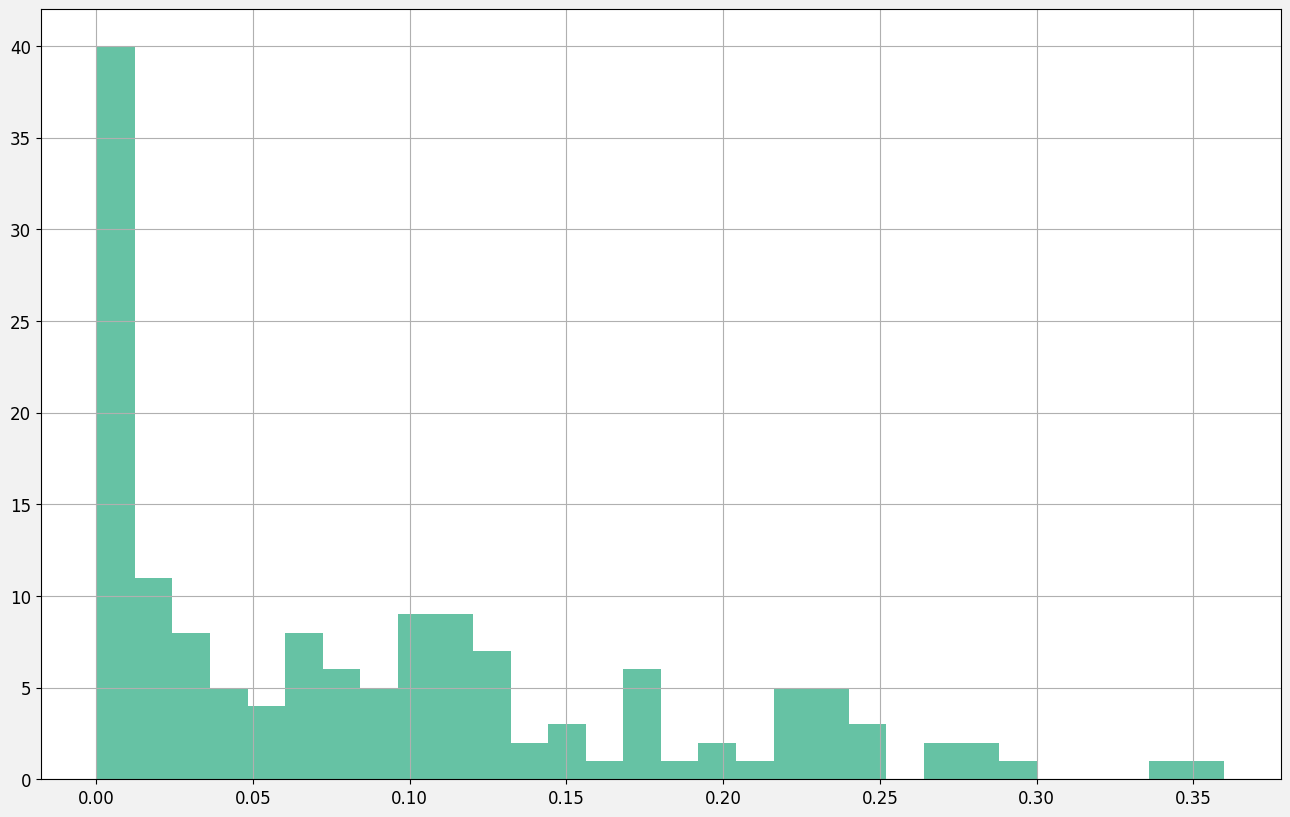

In [34]:
pwt2019Plus['cases_per_pers'].hist(bins = 30)
plt.show()

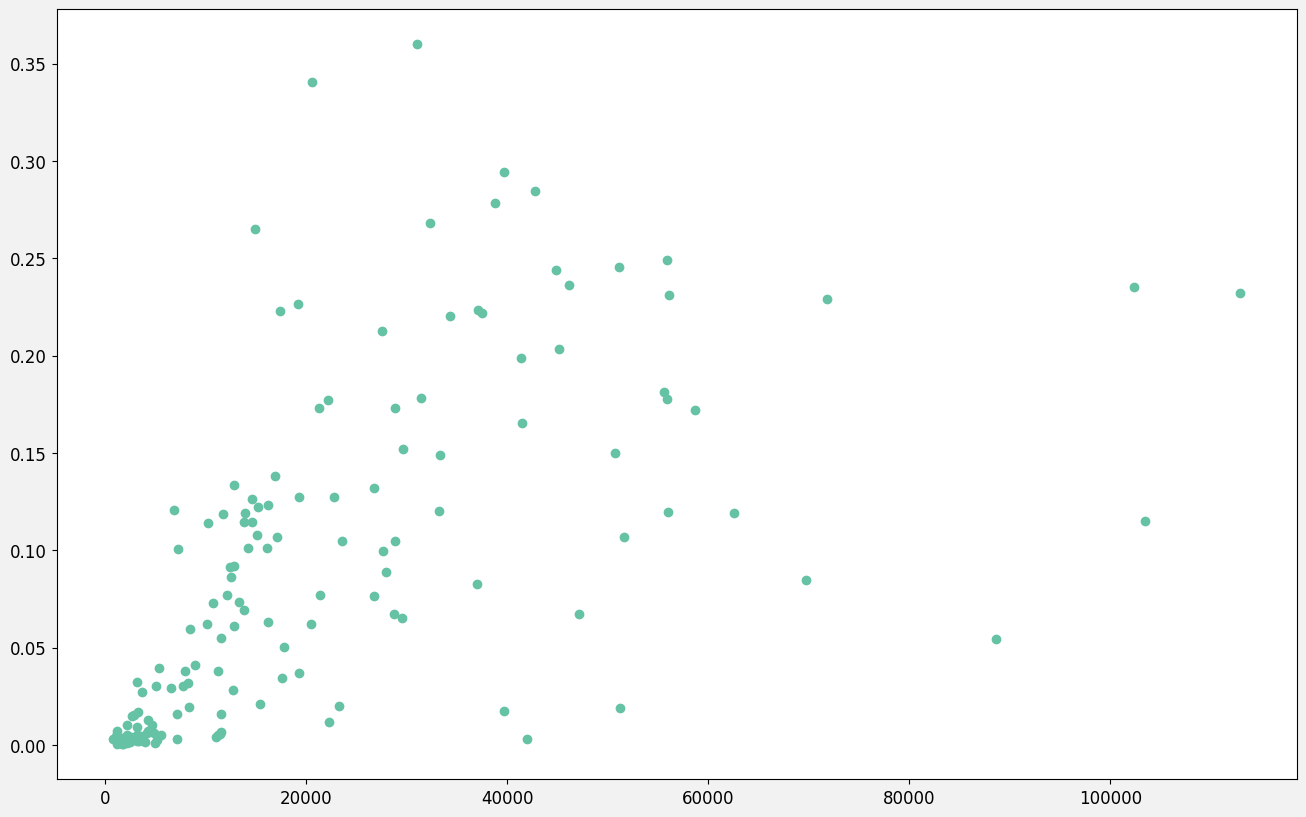

In [35]:
plt.scatter(pwt2019Plus['rgdpe_per_pers'], pwt2019Plus['cases_per_pers'])
plt.show()